In [2]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards

In [3]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)


In [23]:
Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
# Ts_GBT_OPT = [2**i for i in np.arange(7,8)]+[150,175,200,225]+[2**i for i in np.arange(8,10)]+[750]+[1024,1250,1500,2048]
# steps = [int(i) for i in np.arange(1,8)]
step = 6
PREWARDS = []
PREGRETS = []
fn = f"../results/PAFM/RF_pe_w_time128_2048_lookahead{step}_reps{0}.npz"
data = np.load(fn)
states = data["future_states"]
prewards = []
pregrets = []
for k,T in enumerate(Ts):
    irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
    preward = compute_normalized_future_rewards(irewards,100,0.5)
    path, ireward_opt = path_opt(states[k,0], T, 100)
    preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
    pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
    prewards.append(np.sum(preward).item())
    pregrets.append(pregret)
PREWARDS.append(prewards)
PREGRETS.append(pregrets)
PREWARDS_arr = np.vstack(PREWARDS)
PREGRETS_PAFM_pe_arr = np.vstack(PREGRETS).reshape(-1,1)

PREWARDS = []
PREGRETS = []
fn = f"../results/PAFM/RF_oh_w_time128_2048_lookahead{step}_reps{0}.npz"
data = np.load(fn)
states = data["future_states"]
prewards = []
pregrets = []
for k,T in enumerate(Ts):
    irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
    preward = compute_normalized_future_rewards(irewards,100,0.5)
    path, ireward_opt = path_opt(states[k,0], T, 100)
    preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
    pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
    prewards.append(np.sum(preward).item())
    pregrets.append(pregret)
PREWARDS.append(prewards)
PREGRETS.append(pregrets)
PREWARDS_arr = np.vstack(PREWARDS)
PREGRETS_PAFM_oh_arr = np.vstack(PREGRETS).reshape(-1,1)


PREWARDS = []
PREGRETS = []
fn = f"../results/PAFM/RF_optimal_oh_w_time128_2048_lookahead{step}_reps{0}.npz"
data = np.load(fn)
states = data["future_states"]
print(states.shape)
prewards = []
pregrets = []
for k,T in enumerate(Ts):
    irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
    preward = compute_normalized_future_rewards(irewards,100,0.5)
    path, ireward_opt = path_opt(states[k,0], T, 100)
    preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
    pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
    prewards.append(np.sum(preward).item())
    pregrets.append(pregret)
PREWARDS.append(prewards)
PREGRETS.append(pregrets)
PREWARDS_arr = np.vstack(PREWARDS)
PREGRETS_PAFM_opt_arr = np.vstack(PREGRETS).reshape(-1,1)

PREWARDS = []
PREGRETS = []
fn = f"../results/PAFM/GBT_optimal_oh_w_time128_2048_lookahead{step}_reps{0}.npz"
data = np.load(fn)
states = data["future_states"]
print(states.shape)
prewards = []
pregrets = []
for k,T in enumerate(Ts):
    irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
    preward = compute_normalized_future_rewards(irewards,100,0.5)
    path, ireward_opt = path_opt(states[k,0], T, 100)
    preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
    pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
    prewards.append(np.sum(preward).item())
    pregrets.append(pregret)
PREWARDS.append(prewards)
PREGRETS.append(pregrets)
PREWARDS_arr = np.vstack(PREWARDS)
PREGRETS_PAFM_opt_GBT_arr = np.vstack(PREGRETS).reshape(-1,1)



(8, 101)
(8, 101)


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_73449/3588448747.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


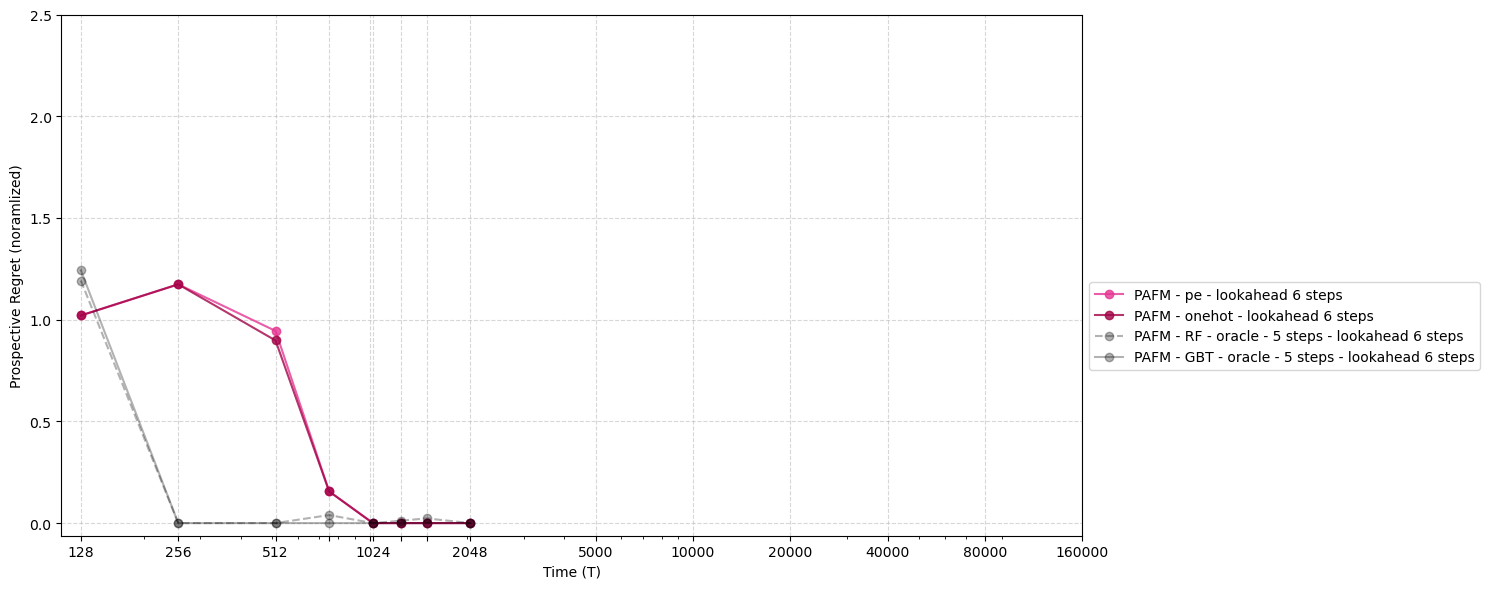

In [25]:
plt.figure(figsize=(15, 6))
Ts_PAFM = Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
Ts_PAFM_ORF = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
Ts_PVFM = [1000,5000,10000,20000,40000,80000,160000]

def get_close_colors(cmap_name, start=0.5, delta=0.15,n = 2):
    cmap = cm.get_cmap(cmap_name)
    cmap_color = [cmap(start + i*delta) for i in range(n)]
    return cmap_color[:n]

# PAFM: purple/red family
pafm_pe_orf, pafm_oh_orf,pafm_pe, pafm_oh = get_close_colors("PuRd", start=0.1, delta=0.25,n = 4)

# PVFM onehot: greens/blues
pvfm_oh_lookahead,pvfm_pe_lookahead, pvfm_oh_wo, pvfm_pe_wo = get_close_colors("GnBu", start=0.95, delta=-0.2,n = 4)

# # PVFM pe: yellow/blue
pvfm_oh_wo_MLP, pvfm_pe_wo_MLP= get_close_colors("YlOrBr", start=0.6, delta=0.2)

# # PA/VFM pe: orange/red
pavfm_oh_rf_3,pavfm_oh_rf,pavfm_pe_rf = get_close_colors("OrRd", start=0.5, delta=0.4,n = 3)

colors = {
    "PAFM_pe": pafm_pe,
    "PAFM_oh": pafm_oh,
    "PAFM_pe_ORF": pafm_pe_orf,
    "PAFM_oh_ORF": pafm_oh_orf,
    "PVFM_pe": pvfm_pe_lookahead,
    "PVFM_pe_wo": pvfm_pe_wo,
    "PVFM_oh": pvfm_oh_lookahead,
    "PVFM_oh_wo": pvfm_oh_wo,
    "PVFM_pe_MLP": pvfm_pe_wo_MLP,
    "PVFM_oh_MLP": pvfm_oh_wo_MLP,
    "PAVFM_oh":pavfm_oh_rf,
    "PAFM_oh_3steps":pavfm_oh_rf_3
}

plt.plot(Ts_PAFM, PREGRETS_PAFM_pe_arr, alpha=0.8, marker='o', color=colors["PAFM_pe"], 
         label='PAFM - pe - lookahead 6 steps')
plt.plot(Ts_PAFM, PREGRETS_PAFM_oh_arr, alpha=0.8, marker='o', color=colors["PAFM_oh"], 
         label='PAFM - onehot - lookahead 6 steps')
plt.plot(Ts_PAFM, PREGRETS_PAFM_opt_arr, alpha=0.3, marker='o', color= 'black',linestyle = '--',
         label='PAFM - RF - oracle - 5 steps - lookahead 6 steps')
plt.plot(Ts_PAFM, PREGRETS_PAFM_opt_GBT_arr, alpha=0.3, marker='o', color= 'black',linestyle = '-',
         label='PAFM - GBT - oracle - 5 steps - lookahead 6 steps')


# plt.plot(Ts_PAFM_ORF, PREGRETS_PAFM_pe_ORF_arr.reshape(-1,1), alpha=0.8, marker='o', color=colors["PAFM_pe_ORF"], 
#          label='PAFM - ORF - pe - lookahead 6 steps')
# plt.plot(Ts_PAFM_ORF, PREGRETS_PAFM_oh_ORF_arr.reshape(-1,1), alpha=0.8, marker='o', color=colors["PAFM_oh_ORF"], 
#          label='PAFM - ORF - onehot - lookahead 6 steps')

         

# plt.plot(Ts_PVFM[:-1], PREGRETS_PVFM_pe_lookahead_arr[5,:], alpha=0.8, marker='o',
#          color=colors["PVFM_pe"], label='PVFM - pe - lookahead-approx 6 steps')
# plt.plot(Ts_PVFM[:-1], PREGRETS_PVFM_oh_lookahead_arr[5,:], alpha=0.8, marker='o',
#          color=colors["PVFM_oh"], label='PVFM - onehot - lookahead-approx 6 steps')
# plt.plot(Ts_PVFM[:-1], PREGRETS_PVFM_pe_lookaheadback_arr.reshape(-1,1), alpha=0.3, marker='o',
#          color=colors["PVFM_pe"], label='PVFM - pe - lookahead-backward 6 steps')
# plt.plot(Ts_PVFM[:-1], PREGRETS_PVFM_oh_lookaheadback_arr.reshape(-1,1), alpha=0.3, marker='o',
#          color=colors["PVFM_oh"], label='PVFM - onehot - lookahead-backward 6 steps')
# plt.plot(Ts_PVFM, PREGRETS_PVFM_pe_arr, alpha=0.8,marker='o',color=colors["PVFM_pe_wo"], 
#          label='PVFM - pe - wo/lookahead')
# plt.plot(Ts_PVFM, PREGRETS_PVFM_oh_arr, alpha=0.8, marker='o',color=colors["PVFM_oh_wo"], 
#          label='PVFM - onehot - wo/lookahead')

# plt.plot(Ts_PVFM, PREGRETS_PVFM_oh_MLP_arr, alpha=0.5, marker='o',color=colors["PVFM_oh_MLP"], 
#          label='PVFM - MLP - onehot - wo/lookahead')
# plt.plot(Ts_PVFM, PREGRETS_PVFM_pe_MLP_arr, alpha=0.5, marker='o',color=colors["PVFM_pe_MLP"], 
#          label='PVFM - MLP - pe - wo/lookahead')

# plt.plot(Ts_PAFM, PREGRETS_PAFM_oh_arr[2,:], alpha=0.8, marker='o', color=colors["PAFM_oh_3steps"], 
#          label='PAFM - onehot - lookahead 3 steps')
# plt.plot(Ts_PVFM[:6], PREGRETS_PAVFM_oh_arr, alpha=0.8, marker='o',color=colors["PAVFM_oh"], 
#          label='PA-VFM - RF -onehot lookahead 3 steps')




plt.xlabel("Time (T)")
plt.ylabel("Prospective Regret (noramlized)")
plt.xscale('log')

xticks = Ts_PAFM + Ts_PVFM 
xticklabels = [str(v) if v in [128,256,512,1024,2048,5000,10000,20000,40000,80000,160000] else ""   # hide every 2nd label
               for i, v in enumerate(xticks)]
plt.xticks(xticks, labels=xticklabels)

# plt.xticks(Ts_PAFM+Ts_PVFM, labels=[str(v) for v in Ts_PAFM+Ts_PVFM])
plt.yticks([0,0.5,1,1.5,2,2.5])
# plt.title('Prospective Regret Across Lookahead Steps - PVFM - PE')
# plt.xlim(0,700000)                  
plt.legend(loc="upper left", bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.show()

